# Zero-Shot Generalisation — All 3 Held-Out Families
All 4 trained models are tested on **KleinGordon**, **ReactionDiffusion**, and **Beam** — three families they have **never seen during training**.

- **KleinGordon**: `u_tt - u_xx + m²u = 0` — wave-like but with a mass term
- **ReactionDiffusion**: `u_t = D·u_xx + r·u·(1-u)` — diffusion + nonlinear logistic growth
- **Beam**: `u_tt + b·u_xxxx = 0` — second-order time but *fourth-order* space

**If a model truly understands PDE structure**, it should recognise structural similarities to training families. If it only memorized templates, it will produce random/wrong outputs.

## 1. Setup

In [22]:
import json
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from transformers import T5Tokenizer, T5ForConditionalGeneration
import evaluate

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'Device: {device}')

Device: mps


In [23]:
DIALECTS = ['natural', 'latex', 'prefix', 'postfix']
MODELS_DIR = '/Users/krivansemlani/Nlp-group-final-project/models'
MAX_INPUT_LENGTH  = 256
MAX_OUTPUT_LENGTH = 256

# All three held-out families with their dataset paths and expected closest training family
HELD_OUT_FAMILIES = {
    'KleinGordon': {
        'path'    : '/Users/krivansemlani/Nlp-group-final-project/varied_data_generation/held_out_kleingordon.jsonl',
        'closest' : 'Wave',       # second-order time + space, like Wave
        'keywords': ['second-order', 'wave', 'mass', 'u_tt', 'u_xx'],
    },
    'ReactionDiffusion': {
        'path'    : '/Users/krivansemlani/Nlp-group-final-project/varied_data_generation/held_out_reactiondiffusion.jsonl',
        'closest' : 'Heat or Burgers',   # ambiguous — has diffusion AND nonlinear term
        'keywords': ['diffus', 'nonlinear', 'second-order', 'reaction'],
    },
    'Beam': {
        'path'    : '/Users/krivansemlani/Nlp-group-final-project/varied_data_generation/held_out_beam.jsonl',
        'closest' : 'Wave',       # second-order time, but fourth-order space
        'keywords': ['second-order', 'fourth', 'wave', 'u_tt'],
    },
}

print('Config ready. Held-out families:', list(HELD_OUT_FAMILIES.keys()))

Config ready. Held-out families: ['KleinGordon', 'ReactionDiffusion', 'Beam']


## 2. Load Held-Out Datasets

In [24]:
held_out_data = {}

for family_name, cfg in HELD_OUT_FAMILIES.items():
    data = []
    with open(cfg['path']) as f:
        for line in f:
            data.append(json.loads(line.strip()))
    data = data[:500]   # first 500 for speed
    held_out_data[family_name] = data
    print(f'{family_name}: {len(data)} instances loaded')
    print(f'  Sample natural : {data[0]["dialects"]["natural"][:80]}')
    print(f'  Sample postfix : {data[0]["dialects"]["postfix"][:80]}')
    print(f'  Sample reasoning: {data[0]["labels"]["reasoning"][:80]}')
    print()

KleinGordon: 500 instances loaded
  Sample natural : The Klein-Gordon structure: temporal curvature minus spatial curvature plus 0.98
  Sample postfix : -1 u(t, x) x d x d * 0.960400000000000 u(t, x) * + u(t, x) t d t d + 0 =
  Sample reasoning: u_tt and u_xx both appear (wave-like), plus a linear restoring term 0.98^2 * u —

ReactionDiffusion: 500 instances loaded
  Sample natural : Diffusion with rate 0.22 and logistic growth with rate 0.34: the temporal change
  Sample postfix : u(t, x) t d 0.220000000000000 u(t, x) x d x d * 0.340000000000000 1 -1 u(t, x) *
  Sample reasoning: First-order in time, second-order in space for diffusion (0.22*u_xx), plus a non

Beam: 500 instances loaded
  Sample natural : u evolves as a vibrating beam: u_tt plus 0.71 times the fourth derivative of u w
  Sample postfix : 0.710000000000000 u(t, x) x d x d x d x d * u(t, x) t d t d + 0 =
  Sample reasoning: Unlike wave (u_xx) or heat (u_xx), this equation has u_xxxx — a fourth-order spa



## 3. Helper Functions

In [25]:
rouge = evaluate.load('rouge')


def get_best_checkpoint(dialect):
    model_dir = os.path.join(MODELS_DIR, dialect)
    checkpoints = [
        os.path.join(model_dir, d) for d in os.listdir(model_dir)
        if d.startswith('checkpoint-')
    ]
    return sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))[-1]


def parse_prediction(pred):
    result = {'family': None, 'operators': [], 'reasoning': ''}
    try:
        for part in pred.split(' | '):
            part = part.strip()
            if part.startswith('family:'):
                result['family'] = part.replace('family:', '').strip()
            elif part.startswith('operators:'):
                ops = part.replace('operators:', '').strip()
                result['operators'] = [o.strip() for o in ops.split(',') if o.strip()]
            elif part.startswith('reasoning:'):
                result['reasoning'] = part.replace('reasoning:', '').strip()
    except Exception:
        pass
    return result


def run_inference(model, tokenizer, data, dialect):
    model.eval()
    model.to('cpu')
    predictions = []
    for i in range(0, len(data), 16):
        batch = data[i:i+16]
        inputs_text = [d['dialects'][dialect] for d in batch]
        enc = tokenizer(
            inputs_text,
            return_tensors='pt',
            max_length=MAX_INPUT_LENGTH,
            truncation=True,
            padding=True,
        )
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=MAX_OUTPUT_LENGTH)
        predictions.extend(tokenizer.batch_decode(out, skip_special_tokens=True))
    return predictions


def evaluate_held_out(predictions_raw, data, keywords):
    """Evaluate zero-shot predictions for a single held-out family."""
    parsed = [parse_prediction(p) for p in predictions_raw]

    # 1. What family does the model predict?
    family_counts = {}
    for p in parsed:
        fam = p['family'] if p['family'] else 'unknown'
        family_counts[fam] = family_counts.get(fam, 0) + 1

    # 2. Reasoning ROUGE-L vs ground truth
    true_reasoning = [d['labels']['reasoning'] for d in data]
    pred_reasoning = [p['reasoning'] for p in parsed]
    rouge_scores = rouge.compute(
        predictions=pred_reasoning,
        references=true_reasoning,
        rouge_types=['rougeL']
    )

    # 3. Structural keyword hit rate
    keyword_hits = sum(
        1 for p in parsed
        if any(kw.lower() in p['reasoning'].lower() for kw in keywords)
    )
    keyword_rate = keyword_hits / len(parsed)

    return {
        'family_distribution'   : family_counts,
        'reasoning_rouge_l'     : rouge_scores['rougeL'],
        'structural_keyword_rate': keyword_rate,
    }


print('Helpers ready.')

Helpers ready.


## 4. Run Zero-Shot Evaluation (all 3 families × 4 models)

In [26]:
tokenizer = T5Tokenizer.from_pretrained('t5-small')

# all_results[family_name][dialect] = {family_distribution, reasoning_rouge_l, structural_keyword_rate}
all_results = {fam: {} for fam in HELD_OUT_FAMILIES}

for dialect in DIALECTS:
    print(f'\n=== Model trained on: {dialect.upper()} ===')
    checkpoint = get_best_checkpoint(dialect)
    model = T5ForConditionalGeneration.from_pretrained(checkpoint)

    for family_name, cfg in HELD_OUT_FAMILIES.items():
        data     = held_out_data[family_name]
        keywords = cfg['keywords']
        preds    = run_inference(model, tokenizer, data, dialect)
        results  = evaluate_held_out(preds, data, keywords)
        all_results[family_name][dialect] = results

        top_fam = max(results['family_distribution'], key=results['family_distribution'].get)
        print(f'  [{family_name}]  ROUGE-L={results["reasoning_rouge_l"]:.2%}  '
              f'KW-hit={results["structural_keyword_rate"]:.2%}  '
              f'top-pred={top_fam}')

    del model

print('\nAll done!')


=== Model trained on: NATURAL ===


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 5806.46it/s]


  [KleinGordon]  ROUGE-L=26.76%  KW-hit=99.80%  top-pred=Wave
  [ReactionDiffusion]  ROUGE-L=26.05%  KW-hit=98.00%  top-pred=Heat
  [Beam]  ROUGE-L=25.90%  KW-hit=64.60%  top-pred=Advection

=== Model trained on: LATEX ===


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 4730.59it/s]


  [KleinGordon]  ROUGE-L=19.26%  KW-hit=100.00%  top-pred=Burgers
  [ReactionDiffusion]  ROUGE-L=23.86%  KW-hit=100.00%  top-pred=Heat
  [Beam]  ROUGE-L=28.64%  KW-hit=100.00%  top-pred=Wave

=== Model trained on: PREFIX ===


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 5040.44it/s]


  [KleinGordon]  ROUGE-L=22.04%  KW-hit=100.00%  top-pred=Wave
  [ReactionDiffusion]  ROUGE-L=26.07%  KW-hit=100.00%  top-pred=Burgers
  [Beam]  ROUGE-L=24.65%  KW-hit=100.00%  top-pred=Wave

=== Model trained on: POSTFIX ===


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 7005.39it/s]


  [KleinGordon]  ROUGE-L=14.74%  KW-hit=100.00%  top-pred=Advection
  [ReactionDiffusion]  ROUGE-L=21.97%  KW-hit=100.00%  top-pred=Heat
  [Beam]  ROUGE-L=23.93%  KW-hit=1.00%  top-pred=Advection

All done!


## 5. Results Tables & Visualisation

=== KLEINGORDON ZERO-SHOT ===


,Top predicted family,ROUGE-L,Structural keyword %
Model (trained on),,,
Natural,Wave,26.76%,99.80%
Latex,Burgers,19.26%,100.00%
Prefix,Wave,22.04%,100.00%
Postfix,Advection,14.74%,100.00%



=== REACTIONDIFFUSION ZERO-SHOT ===


,Top predicted family,ROUGE-L,Structural keyword %
Model (trained on),,,
Natural,Heat,26.05%,98.00%
Latex,Heat,23.86%,100.00%
Prefix,Burgers,26.07%,100.00%
Postfix,Heat,21.97%,100.00%



=== BEAM ZERO-SHOT ===


,Top predicted family,ROUGE-L,Structural keyword %
Model (trained on),,,
Natural,Advection,25.90%,64.60%
Latex,Wave,28.64%,100.00%
Prefix,Wave,24.65%,100.00%
Postfix,Advection,23.93%,1.00%



CSVs saved.


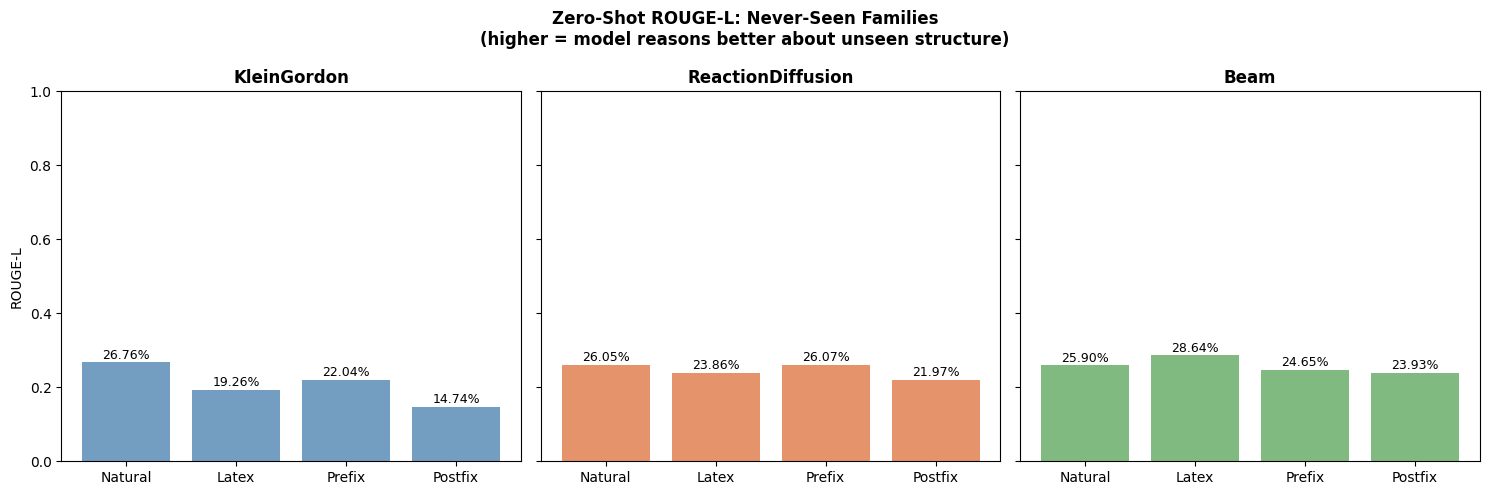

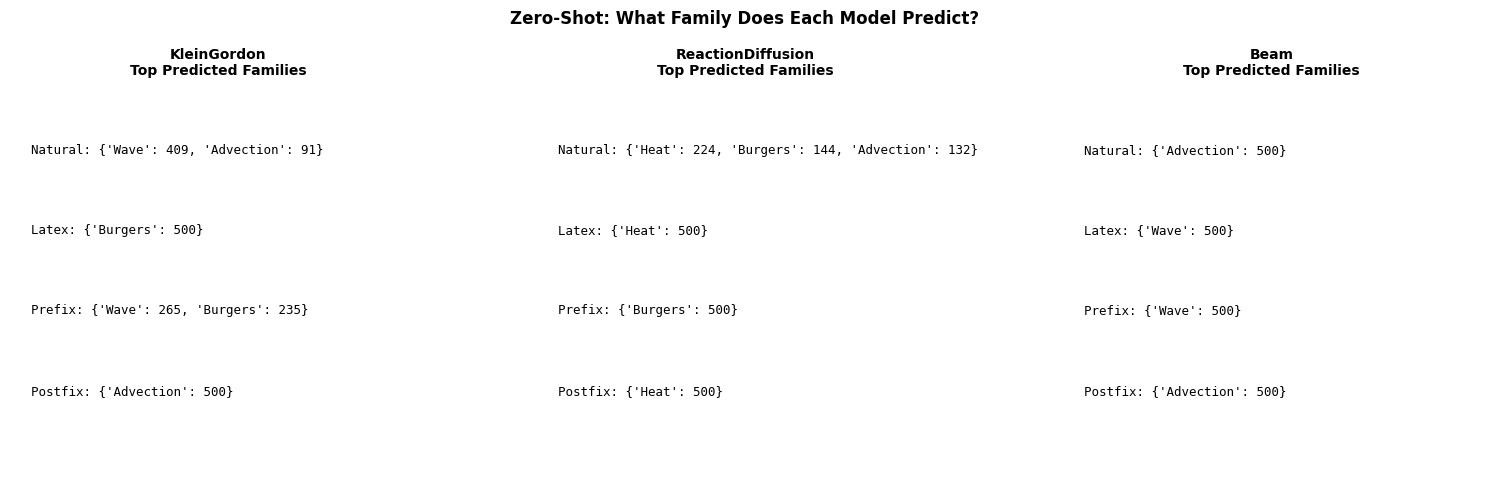

Saved zeroshot_rouge_all.png and zeroshot_family_preds.png


In [27]:
FAMILY_NAMES = list(HELD_OUT_FAMILIES.keys())

# ── Per-family tables ──────────────────────────────────────────────────────────
for family_name in FAMILY_NAMES:
    rows = []
    for dialect in DIALECTS:
        r = all_results[family_name][dialect]
        top_family = max(r['family_distribution'], key=r['family_distribution'].get)
        rows.append({
            'Model (trained on)'   : dialect.capitalize(),
            'Top predicted family' : top_family,
            'ROUGE-L'              : f"{r['reasoning_rouge_l']:.2%}",
            'Structural keyword %' : f"{r['structural_keyword_rate']:.2%}",
        })
    df = pd.DataFrame(rows).set_index('Model (trained on)')
    print(f'=== {family_name.upper()} ZERO-SHOT ===')
    display(df)
    print()

# ── Save CSVs ─────────────────────────────────────────────────────────────────
for family_name in FAMILY_NAMES:
    rows = []
    for dialect in DIALECTS:
        r = all_results[family_name][dialect]
        rows.append({
            'dialect'      : dialect,
            'rouge_l'      : r['reasoning_rouge_l'],
            'keyword_rate' : r['structural_keyword_rate'],
            'top_family'   : max(r['family_distribution'], key=r['family_distribution'].get),
        })
    pd.DataFrame(rows).to_csv(f'zeroshot_{family_name.lower()}.csv', index=False)
print('CSVs saved.')

# ── ROUGE-L bar chart (one subplot per family) ────────────────────────────────
dialect_labels = [d.capitalize() for d in DIALECTS]
colors = ['#5B8DB8', '#E08050', '#6BAE6B']

fig, axes = plt.subplots(1, len(FAMILY_NAMES), figsize=(5 * len(FAMILY_NAMES), 5), sharey=True)

for ax, family_name, color in zip(axes, FAMILY_NAMES, colors):
    vals = [all_results[family_name][d]['reasoning_rouge_l'] for d in DIALECTS]
    ax.bar(dialect_labels, vals, color=color, alpha=0.85)
    ax.set_title(family_name, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('ROUGE-L' if ax == axes[0] else '')
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01, f'{v:.2%}', ha='center', fontsize=9)

plt.suptitle('Zero-Shot ROUGE-L: Never-Seen Families\n(higher = model reasons better about unseen structure)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('zeroshot_rouge_all.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top-predicted family heatmap: rows=dialect, cols=family ───────────────────
# Encode as: correct-ish (Wave for KG/Beam) vs wrong
import matplotlib.patches as mpatches

fig2, axes2 = plt.subplots(1, len(FAMILY_NAMES), figsize=(5 * len(FAMILY_NAMES), 5))

for ax, family_name in zip(axes2, FAMILY_NAMES):
    # Build a small confusion-like table: what does each model predict?
    pred_table = {}
    for dialect in DIALECTS:
        dist = all_results[family_name][dialect]['family_distribution']
        pred_table[dialect.capitalize()] = dict(
            sorted(dist.items(), key=lambda x: -x[1])[:3]
        )
    text_rows = [f"{k}: {v}" for k, v in pred_table.items()]
    ax.axis('off')
    ax.set_title(f'{family_name}\nTop Predicted Families', fontweight='bold', fontsize=10)
    for j, row in enumerate(text_rows):
        ax.text(0.05, 0.85 - j * 0.2, row, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', fontfamily='monospace')

plt.suptitle('Zero-Shot: What Family Does Each Model Predict?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('zeroshot_family_preds.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved zeroshot_rouge_all.png and zeroshot_family_preds.png')

## 6. Sample Predictions (1 instance per family × 4 models)

In [28]:
tokenizer = T5Tokenizer.from_pretrained('t5-small')

print('=== SAMPLE ZERO-SHOT PREDICTIONS (never-seen families) ===\n')

for family_name, cfg in HELD_OUT_FAMILIES.items():
    sample = held_out_data[family_name][:2]
    print(f'{"="*60}')
    print(f'FAMILY: {family_name}  (closest training family: {cfg["closest"]})')
    print(f'{"="*60}')

    for dialect in DIALECTS:
        checkpoint = get_best_checkpoint(dialect)
        model = T5ForConditionalGeneration.from_pretrained(checkpoint)
        model.eval()
        model.to('cpu')

        print(f'\n  -- Model trained on {dialect.upper()} --')
        for d in sample:
            enc = tokenizer(
                d['dialects'][dialect],
                return_tensors='pt',
                max_length=MAX_INPUT_LENGTH,
                truncation=True,
            )
            with torch.no_grad():
                out = model.generate(**enc, max_new_tokens=MAX_OUTPUT_LENGTH)
            pred = tokenizer.decode(out[0], skip_special_tokens=True)
            print(f'    Input : {d["dialects"][dialect][:90]}...')
            print(f'    Output: {pred[:130]}')
            print()
        del model
    print()

=== SAMPLE ZERO-SHOT PREDICTIONS (never-seen families) ===

FAMILY: KleinGordon  (closest training family: Wave)


Loading weights: 100%|██████████| 131/131 [00:00<00:00, 7035.53it/s]


  -- Model trained on NATURAL --


    Input : The Klein-Gordon structure: temporal curvature minus spatial curvature plus 0.98^2 times u...
    Output: family: Wave | operators: sin, cos, polynomial | reasoning: Second-order temporal and spatial derivatives both present, with speed

    Input : Second-order time and space derivatives of u differ by a mass correction: u_tt - u_xx + 0....
    Output: family: Wave | operators: sin, cos, polynomial | reasoning: Contains a second-order time derivative and second-order spatial deriv



Loading weights: 100%|██████████| 131/131 [00:00<00:00, 6327.85it/s]


...


  -- Model trained on PREFIX --
    Input : =(+(*(0.710000000000000, d(d(d(d(u(t, x), x), x), x), x)), d(d(u(t, x), t), t)), 0)...
    Output: family: Wave | operators: sin, cos, polynomial | reasoning: Contains a second-order time derivative and second-order spatial deriv



    Input : =(+(*(1.89000000000000, d(d(d(d(u(t, x), x), x), x), x)), d(d(u(t, x), t), t)), 0)...
    Output: family: Wave | operators: sin, cos, polynomial | reasoning: Second-order temporal and spatial derivatives both present, with speed



Loading weights: 100%|██████████| 131/131 [00:00<00:00, 27245.19it/s]


  -- Model trained on POSTFIX --


    Input : 0.710000000000000 u(t, x) x d x d x d x d * u(t, x) t d t d + 0 =...
    Output: family: Advection | operators: exp, polynomial | reasoning: Only first-order derivatives appear: u_t and 0.71*u_x, with no u_xx te

    Input : 1.89000000000000 u(t, x) x d x d x d x d * u(t, x) t d t d + 0 =...
    Output: family: Advection | operators: exp, polynomial | reasoning: Only first-order derivatives appear: u_t and 1.89*u_x, with no u_xx te


